<a href="https://colab.research.google.com/github/AhmadFebriyan5/KKN-Simulation/blob/main/KNN_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bagian 2: Simulasi K-Nearest Neighbors (KNN)
Lecture 6: Learning — Mark Hasegawa-Johnson

Notebook ini mensimulasikan klasifikasi anjing vs kucing (slide 17-21) dan mendemonstrasikan:
1. Efek nilai K terlalu kecil (K=1) terhadap unusual training tokens
2. Mengapa KNN membutuhkan memori lebih besar dibanding Decision Tree (Non-Parametric Learner)

In [1]:
# Cell 1: Import Library
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
import pickle, sys, warnings
warnings.filterwarnings('ignore')

In [2]:
# Cell 2: Buat Dataset Anjing vs Kucing dengan Outlier
# Fitur X1 = ukuran tubuh, X2 = panjang bulu
# Label 0 = Kucing, Label 1 = Anjing

np.random.seed(42)

n = 30
cats    = np.column_stack([np.random.normal(2.0, 0.5, n), np.random.normal(3.0, 0.6, n)])
dogs    = np.column_stack([np.random.normal(5.0, 0.6, n), np.random.normal(2.0, 0.5, n)])
outlier = np.array([[2.3, 2.9]])  # anjing dengan fitur mirip kucing

X = np.vstack([cats, dogs, outlier])
y = np.array([0]*n + [1]*n + [1])  # 0=kucing, 1=anjing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Training: {len(X_train)} sampel | Test: {len(X_test)} sampel')
print('Outlier: 1 anjing ditempatkan di wilayah kucing (X1=2.3, X2=2.9)')

Training: 42 sampel | Test: 19 sampel
Outlier: 1 anjing ditempatkan di wilayah kucing (X1=2.3, X2=2.9)


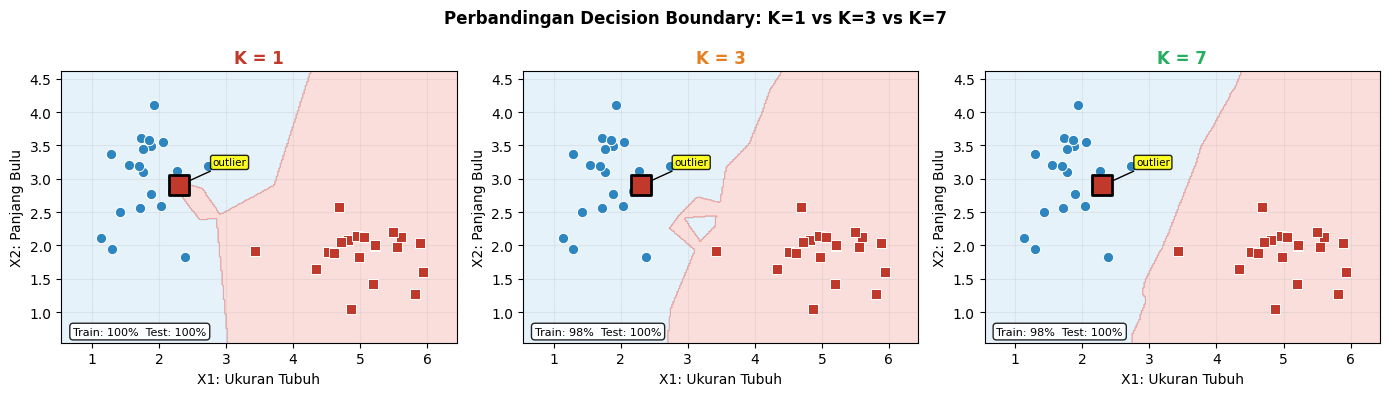

K=1  : Boundary berlekuk, outlier menciptakan pulau salah klasifikasi
K=3  : Lebih halus, outlier dinetralisir oleh suara mayoritas
K=7  : Sangat halus, risiko underfitting pada pola lokal


In [3]:
# Cell 3: Perbandingan Decision Boundary K=1, K=3, K=7

k_values = [1, 3, 7]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cmap_area = ListedColormap(['#AED6F1', '#F1948A'])
x0, x1 = X[:,0].min()-0.5, X[:,0].max()+0.5
y0, y1 = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x0, x1, 300), np.linspace(y0, y1, 300))

for ax, k in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    acc_train = accuracy_score(y_train, knn.predict(X_train))
    acc_test  = accuracy_score(y_test,  knn.predict(X_test))

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_area)

    for cls, color, marker in [(0,'#2E86C1','o'), (1,'#C0392B','s')]:
        mask = y_train == cls
        ax.scatter(X_train[mask,0], X_train[mask,1],
                   c=color, marker=marker, s=55, edgecolors='white', lw=0.7, zorder=3)

    # Tandai outlier jika ada di training set
    for xi, yi in zip(X_train, y_train):
        if abs(xi[0]-2.3) < 0.05 and abs(xi[1]-2.9) < 0.05:
            ax.scatter(xi[0], xi[1], c='#C0392B', marker='s', s=200,
                       edgecolors='black', lw=2, zorder=5)
            ax.annotate('outlier', xy=(xi[0], xi[1]), xytext=(xi[0]+0.5, xi[1]+0.3),
                        fontsize=7.5, arrowprops=dict(arrowstyle='->', lw=1),
                        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.85))

    title_colors = {1: '#C0392B', 3: '#E67E22', 7: '#27AE60'}
    ax.set_title(f'K = {k}', fontweight='bold', color=title_colors[k])
    ax.set_xlabel('X1: Ukuran Tubuh')
    ax.set_ylabel('X2: Panjang Bulu')
    ax.text(0.03, 0.03, f'Train: {acc_train:.0%}  Test: {acc_test:.0%}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.85))
    ax.grid(True, alpha=0.2)

fig.suptitle('Perbandingan Decision Boundary: K=1 vs K=3 vs K=7', fontweight='bold')
plt.tight_layout()
plt.show()

print('K=1  : Boundary berlekuk, outlier menciptakan pulau salah klasifikasi')
print('K=3  : Lebih halus, outlier dinetralisir oleh suara mayoritas')
print('K=7  : Sangat halus, risiko underfitting pada pola lokal')

In [4]:
# Cell 4: Demo Misklasifikasi K=1 vs K>=3 pada Test Token dekat Outlier

test_token = np.array([[2.5, 2.8]])  # seharusnya kucing, tapi dekat outlier anjing

print(f'Test token: X1={test_token[0,0]}, X2={test_token[0,1]} (seharusnya KUCING)')
print('-' * 50)
print(f'{"K":<6} {"Voting (Kucing/Anjing)":<25} {"Prediksi"}')
print('-' * 50)

for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    pred = knn.predict(test_token)[0]
    _, idx = knn.kneighbors(test_token)
    labels = y_train[idx[0]]
    v0, v1 = int((labels==0).sum()), int((labels==1).sum())
    hasil = 'KUCING (benar)' if pred == 0 else 'ANJING (salah)'
    print(f'{k:<6} {v0} kucing vs {v1} anjing{"":>9} {hasil}')

Test token: X1=2.5, X2=2.8 (seharusnya KUCING)
--------------------------------------------------
K      Voting (Kucing/Anjing)    Prediksi
--------------------------------------------------
1      0 kucing vs 1 anjing          ANJING (salah)
3      2 kucing vs 1 anjing          KUCING (benar)
5      4 kucing vs 1 anjing          KUCING (benar)
7      6 kucing vs 1 anjing          KUCING (benar)


    Data |   KNN (KB) |   Decision Tree (KB) |    Rasio
-------------------------------------------------------
      50 |        2.8 |                  1.7 |     1.6x
     200 |        7.8 |                  2.9 |     2.7x
     500 |       18.7 |                  2.8 |     6.7x
   1,000 |       36.3 |                  3.3 |    11.2x
   5,000 |      173.4 |                  3.6 |    48.5x


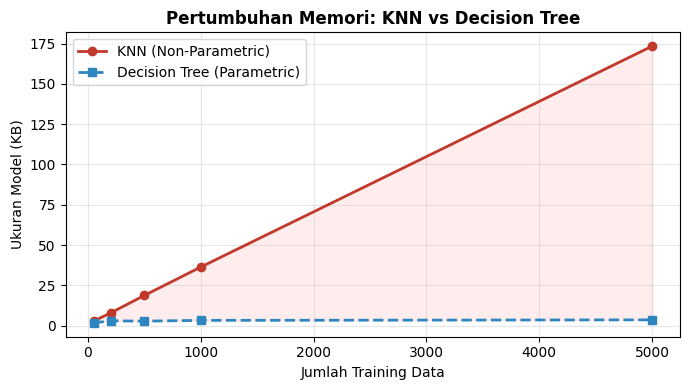


Decision Tree (Parametric, Slide 12):
  Pengetahuan dipadatkan ke parameter terbatas (aturan pohon).
  Data training tidak dibutuhkan saat testing. Memori relatif tetap.

KNN (Non-Parametric, Slide 23):
  Tidak ada parameter yang merangkum f(x).
  Seluruh training database harus tersimpan dan diakses saat testing.
  Memori tumbuh linear seiring bertambahnya data training.


In [5]:
# Cell 5: Perbandingan Memori KNN vs Decision Tree
# Hubungan dengan konsep Non-Parametric vs Parametric Learner (Slide 12, 23)

sizes = [50, 200, 500, 1000, 5000]
knn_mem, dtree_mem = [], []

for n in sizes:
    X_b, y_b = make_classification(n_samples=n, n_features=2,
                                    n_informative=2, n_redundant=0, random_state=42)
    knn   = KNeighborsClassifier(n_neighbors=3).fit(X_b, y_b)
    dtree = DecisionTreeClassifier(max_depth=4).fit(X_b, y_b)
    knn_mem.append(sys.getsizeof(pickle.dumps(knn)) / 1024)
    dtree_mem.append(sys.getsizeof(pickle.dumps(dtree)) / 1024)

# Tabel
print(f'{"Data":>8} | {"KNN (KB)":>10} | {"Decision Tree (KB)":>20} | {"Rasio":>8}')
print('-' * 55)
for n, k, d in zip(sizes, knn_mem, dtree_mem):
    print(f'{n:>8,} | {k:>10.1f} | {d:>20.1f} | {k/d:>7.1f}x')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, knn_mem,   'o-',  color='#C0392B', lw=2, label='KNN (Non-Parametric)')
ax.plot(sizes, dtree_mem, 's--', color='#2E86C1', lw=2, label='Decision Tree (Parametric)')
ax.fill_between(sizes, knn_mem, dtree_mem, alpha=0.07, color='red')
ax.set_xlabel('Jumlah Training Data')
ax.set_ylabel('Ukuran Model (KB)')
ax.set_title('Pertumbuhan Memori: KNN vs Decision Tree', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print('Decision Tree (Parametric, Slide 12):')
print('  Pengetahuan dipadatkan ke parameter terbatas (aturan pohon).')
print('  Data training tidak dibutuhkan saat testing. Memori relatif tetap.')
print()
print('KNN (Non-Parametric, Slide 23):')
print('  Tidak ada parameter yang merangkum f(x).')
print('  Seluruh training database harus tersimpan dan diakses saat testing.')
print('  Memori tumbuh linear seiring bertambahnya data training.')